In [1]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pingouin as pg
import seaborn as sns


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/dff_skewness')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
# fig, ax = plt.subplots(1,1)
rows = []
for mouse in sparse_mice:
    for day in range(6):
        if (mouse == 'SparseKO_09') and (day==2):
            continue 
        sess = u.load_single_day(mouse,day)
        
        for chan in ('channel_0', 'channel_1'):
            skew = sp.stats.skew(sess.timeseries[f'{chan}_F_dff'], axis=1, nan_policy='omit')
            maxs = np.nanmax(sess.timeseries[f'{chan}_F_dff'], axis=1)
            mins = np.nanmin(sess.timeseries[f'{chan}_F_dff'], axis=1)
            for (cell_skew, cell_max, cell_min) in zip(skew, maxs, mins):
                rows.append({'mouse': mouse,
                            'day': day,
                            'chan': chan,
                            'skew': cell_skew,
                            'range': cell_max-cell_min,
                            'max': cell_max})
       
df = pd.DataFrame(rows)



{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1, 'ravel_ind': 0}
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2, 'ravel_ind': 1}
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3, 'ravel_ind': 2}
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4, 'ravel_ind': 3}
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 12, 'novel_arm': -1, 'exp_day': 5, 'ravel_ind': 4}
{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6, 'ravel_ind': 5}
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1, 'ravel_ind': 0}
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 2, 'ravel_ind': 1}
{'date': '28_05_2025', 'scene': 'YMaz

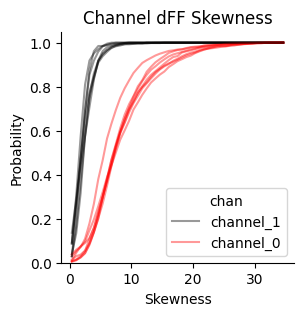

In [4]:
fig, ax = plt.subplots(figsize=[3,3])
bins = np.linspace(0,35)
for mouse in sparse_mice:
    sns.histplot(data = df.loc[df['mouse']==mouse], 
                x = 'skew', 
                hue = 'chan', 
                hue_order = ['channel_1', 'channel_0'],
                palette = ['black', 'red'],
                stat = 'probability',
                cumulative = True,
                fill=False,
                element='poly',
                common_norm = False, 
                alpha=.4,
                bins=bins,
                ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Skewness')
ax.set_title('Channel dFF Skewness')
fig.savefig(figdir / "sparse_dff_skewness.pdf")

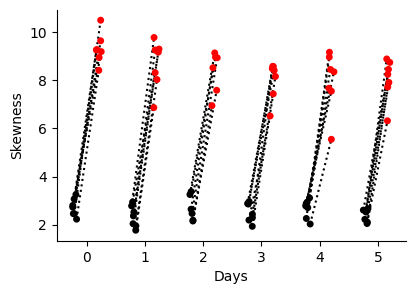

In [5]:
df_mu = df.groupby(['mouse','day','chan'])['skew'].mean().reset_index()

fig,ax = plt.subplots(1,1, figsize=[4.5,3], sharey = True)

sns.stripplot(data=df_mu,
            x='day',
            y='skew',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax,
            legend=False)
for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
            ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



# sns.pointplot(data=df_mu,
#             x='day',
#             y='skew',
#             errorbar=None,
#             hue='chan',
#             hue_order=('channel_1', 'channel_0'), 
#             palette=['black', 'red'],
#             dodge = .4,
#             ax=ax,
#             linestyles="none",
#             marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
#             )


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Days')
ax.set_ylabel('Skewness')
# ax.set_title('Control vs Cre')
fig.savefig(figdir / "sparse_skewness_across_days.pdf")

In [6]:
import pingouin as pg
df['rank_skewness'] = df['skew'].rank()

aov = pg.rm_anova(data=df, dv='rank_skewness', within=['day', 'chan'], subject='mouse')
aov

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,day,3.474869e+06,5,25,6.949737e+05,2.701127,4.385438e-02,8.583628e-02,0.111003,0.577842
1,chan,7.050984e+08,1,5,7.050984e+08,1601.309748,1.837444e-07,1.837444e-07,0.962030,1.000000
2,day * chan,2.968848e+06,5,25,5.937697e+05,8.398385,9.050739e-05,5.257864e-03,0.096396,0.442470


In [11]:
# import statsmodels.api as sm
# from scipy.stats import shapiro, normaltest, anderson
fig = pg.qqplot(aov.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(aov.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(aov.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

AttributeError: 'DataFrame' object has no attribute 'resid'

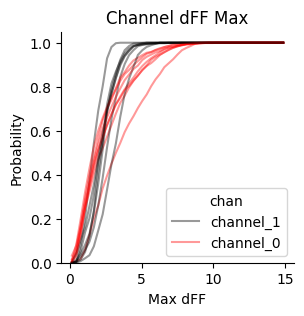

In [7]:
fig, ax = plt.subplots(figsize=[3,3])
bins = np.linspace(0,15)
for mouse in sparse_mice:
    sns.histplot(data = df.loc[df['mouse']==mouse], 
                x = 'max', 
                hue = 'chan', 
                hue_order = ['channel_1', 'channel_0'],
                palette = ['black', 'red'],
                stat = 'probability',
                cumulative = True,
                fill=False,
                element='poly',
                common_norm = False, 
                alpha=.4,
                bins=bins,
                ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Max dFF')
ax.set_title('Channel dFF Max')
fig.savefig(figdir / "sparse_dff_max.pdf")

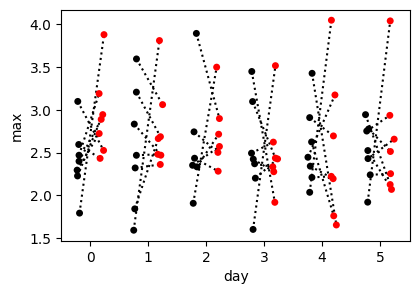

In [8]:
df_mu = df.groupby(['mouse','day','chan'])['max'].mean().reset_index()

fig,ax = plt.subplots(1,1, figsize=[4.5,3], sharey = True)

sns.stripplot(data=df_mu,
            x='day',
            y='max',
            hue='chan', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax,
            legend=False)
for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
            ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

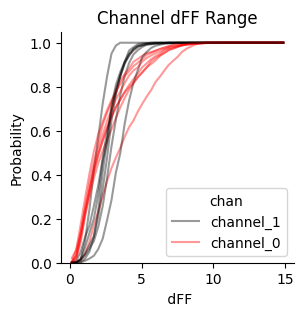

In [9]:
fig, ax = plt.subplots(figsize=[3,3])
bins = np.linspace(0,15)
for mouse in sparse_mice:
    sns.histplot(data = df.loc[df['mouse']==mouse], 
                x = 'range', 
                hue = 'chan', 
                hue_order = ['channel_1', 'channel_0'],
                palette = ['black', 'red'],
                stat = 'probability',
                cumulative = True,
                fill=False,
                element='poly',
                common_norm = False, 
                alpha=.4,
                bins=bins,
                ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(' dFF')
ax.set_title('Channel dFF Range')
fig.savefig(figdir / "sparse_dff_range.pdf")

In [10]:
sparse_sess = u.load_single_day(sparse_mice[0],0)

{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1, 'ravel_ind': 0}


In [11]:
sparse_sess.timeseries['channel_0_F_dff'].shape

(318, 38949)

In [12]:
np.argwhere(sp.stats.skew(sparse_sess.timeseries['channel_0_F_dff'],axis=1, nan_policy='omit')>6)

array([[  0],
       [  1],
       [  2],
       [  3],
       [  4],
       [  5],
       [  6],
       [  7],
       [  8],
       [ 10],
       [ 11],
       [ 12],
       [ 13],
       [ 14],
       [ 15],
       [ 16],
       [ 17],
       [ 18],
       [ 19],
       [ 20],
       [ 21],
       [ 24],
       [ 25],
       [ 26],
       [ 27],
       [ 28],
       [ 29],
       [ 30],
       [ 31],
       [ 32],
       [ 34],
       [ 35],
       [ 36],
       [ 37],
       [ 38],
       [ 39],
       [ 40],
       [ 41],
       [ 42],
       [ 43],
       [ 44],
       [ 45],
       [ 46],
       [ 47],
       [ 48],
       [ 49],
       [ 50],
       [ 51],
       [ 52],
       [ 53],
       [ 54],
       [ 55],
       [ 56],
       [ 57],
       [ 58],
       [ 59],
       [ 60],
       [ 61],
       [ 63],
       [ 64],
       [ 66],
       [ 67],
       [ 68],
       [ 69],
       [ 70],
       [ 71],
       [ 72],
       [ 73],
       [ 74],
       [ 75],
       [ 76],
      

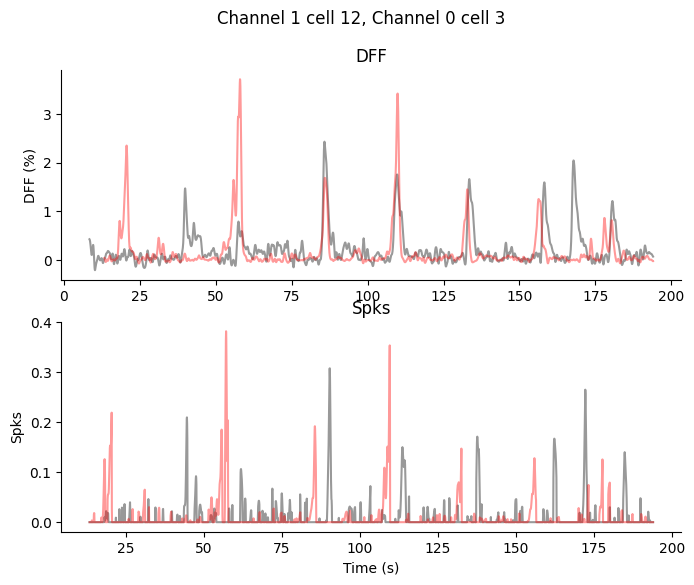

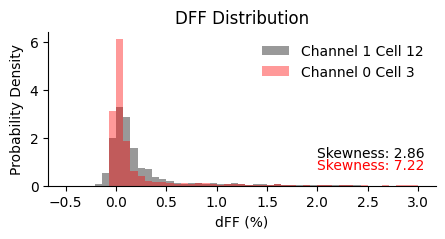

In [30]:
fig, ax = plt.subplots(2,1,figsize=[8,6])
x = np.arange(3000)/15.46
cell1 = 5
_x = 75
ax[0].plot(x, sparse_sess.timeseries['channel_1_F_dff'][cell1,_x:3000+_x], color='black',alpha=.4)
ax[0].plot(x, sparse_sess.timeseries['channel_0_F_dff'][2,:3000], color='red', alpha=.4)

ax[1].plot(x, sparse_sess.timeseries['channel_1_spks'][cell1,:3000], color='black',alpha=.4)
ax[1].plot(x, sparse_sess.timeseries['channel_0_spks'][2,:3000], color='red', alpha=.4)


# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

fig.suptitle('Channel 1 cell 12, Channel 0 cell 3')
ax[0].set_title('DFF')
ax[1].set_title('Spks')
ax[1].set_xlabel('Time (s)')
ax[0].set_ylabel('DFF (%)')
ax[1].set_ylabel('Spks')

for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
fig.savefig(figdir / "SparseKO_02_day0_example_timeseries.pdf")



fig, ax= plt.subplots(figsize=[5,2])
bins = np.linspace(-.5,3)
ax.hist(sparse_sess.timeseries['channel_1_F_dff'][cell1,:3000], bins=bins, color='black', alpha=.4, density=True, cumulative=False,  label='Channel 1 Cell 12')
ax.hist(sparse_sess.timeseries['channel_0_F_dff'][2,:3000], bins=bins, color='red', alpha=.4, density=True, cumulative=False, label='Channel 0 Cell 3')
ax.set_xlabel('dFF (%)')
ax.set_ylabel('Probability Density')
cell1_skew = sp.stats.skew(sparse_sess.timeseries['channel_1_F_dff'][10,:], nan_policy='omit')
cell0_skew = sp.stats.skew(sparse_sess.timeseries['channel_0_F_dff'][2,:], nan_policy='omit')
ax.text(2, 1.2, f'Skewness: {cell1_skew:.2f}', color='black')
ax.text(2, .7, f'Skewness: {cell0_skew:.2f}', color='red')
ax.set_title('DFF Distribution')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)
fig.savefig(figdir / "SparseKO_02_day0_example_dff_histogram.pdf")
# # 


In [12]:
rows = []
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(6):
            
            sess = u.load_single_day(mouse,day)
            
            # for chan in ('channel_0', 'channel_1'):
            skew = sp.stats.skew(sess.timeseries['F_dff'], axis=1, nan_policy='omit')
            print(skew.shape)
            for cell in skew:
                rows.append({'mouse': mouse,
                            'day': day,
                            'cond': cond,
                            'skew': cell})

df = pd.DataFrame(rows)

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
(1381,)
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}
(1093,)
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}
(972,)
{'date': '02_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 3}
(1068,)
{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 4}
(962,)
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
(1370,)
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
(1283,)
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 1}
(1170,)
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ra

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


(1428,)
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
(1030,)
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
(799,)
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 2}
(961,)
{'date': '17_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
(985,)
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 1, 'novel_arm': 1, 'ravel_ind': 4}
(965,)
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 5}
(1079,)
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
(909,)
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 1}
(873,)
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'r

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


(904,)
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}


...

(1233,)
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


(1087,)
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


(1115,)
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
(1148,)
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
(1505,)
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 2}
(1346,)
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
(1389,)
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 4}
(1154,)
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
(1223,)
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
(1578,)
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 1}
(1554,)
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 

In [32]:
df.head()

,mouse,day,cond,skew
0,4467331.1,0,ctrl,3.374950
1,4467331.1,0,ctrl,4.515246
2,4467331.1,0,ctrl,2.509877
3,4467331.1,0,ctrl,2.414171
4,4467331.1,0,ctrl,3.060457


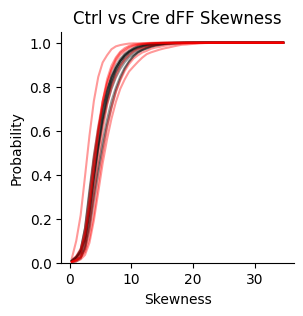

In [33]:
fig, ax = plt.subplots(figsize=[3,3])
bins = np.linspace(0,35)
for cond, mice, color in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice), ('black', 'red')):
    for mouse in mice:
        sns.histplot(data = df.loc[df['mouse']==mouse], 
                    x = 'skew', 
                    # hue = 'chan', 
                    # hue_order = ['channel_1', 'channel_0'],
                    # palette = ['black', 'red'],
                    color=color,
                    stat = 'probability',
                    cumulative = True,
                    fill=False,
                    element='poly',
                    common_norm = False, 
                    alpha=.4,
                    bins=bins,
                    ax=ax)

# clean and save
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Skewness')
ax.set_title('Ctrl vs Cre dFF Skewness')
fig.savefig(figdir / "control_vs_cre_dff_skewness.pdf")

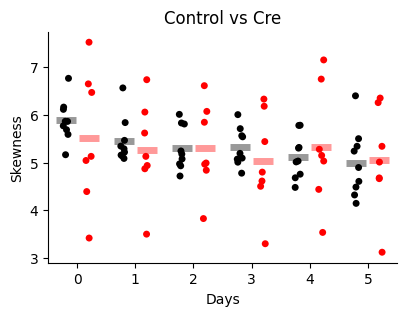

In [34]:
df_mu = df.groupby(['mouse','day','cond'])['skew'].mean().reset_index()

fig,ax = plt.subplots(1,1, figsize=[4.5,3], sharey = True)

sns.stripplot(data=df_mu,
            x='day',
            y='skew',
            hue='cond', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            ax=ax,
            legend=False)



sns.pointplot(data=df_mu,
            x='day',
            y='skew',
            errorbar=None,
            hue='cond',
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge = .4,
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Days')
ax.set_ylabel('Skewness')
ax.set_title('Control vs Cre')
fig.savefig(figdir / "control_v_cre_skewness_across_days.pdf")
# ax[i].set_title(nov)

# for a in ax.flatten():
#     a.spines['top'].set_visible(False)
#     a.spines['right'].set_visible(False)

# clean and save

In [14]:
# mixed effects anova on rank transformed skews
import pingouin as pg
df['rank_skewness'] = df['skew'].rank()

aov = pg.mixed_anova(data=df, dv='skew', within='day', subject='mouse', between='cond')
aov

,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,cond,0.229596,1,14,0.229596,0.061402,8.078911e-01,NaN,0.004367,NaN,NaN,NaN,NaN
1,day,4.488228,5,70,0.897646,9.300819,7.951406e-07,0.000275,0.399163,0.522479,False,0.119971,0.016657
2,Interaction,1.002104,5,70,0.200421,2.076630,7.855903e-02,NaN,0.129171,NaN,NaN,NaN,NaN


In [36]:
# plot example dff from an example cell from ctrl and cre mice
ctrl_sess = u.load_single_day(ctrl_mice[0],5)
ko_sess = u.load_single_day(ko_mice[1],5)



{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': 1, 'ravel_ind': 5}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


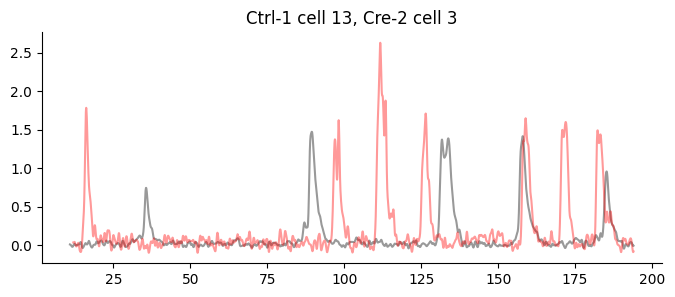

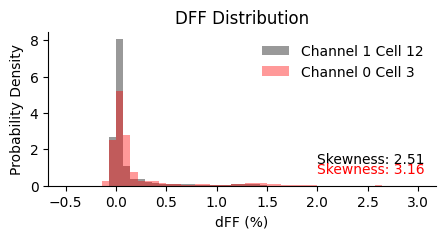

In [41]:
fig, ax = plt.subplots(figsize=[8,3])
x = np.arange(3000)/15.46
ax.plot(x, ctrl_sess.timeseries['F_dff'][12,:3000], color='black',alpha=.4)
ax.plot(x, ko_sess.timeseries['F_dff'][2,:3000], color='red', alpha=.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Ctrl-1 cell 13, Cre-2 cell 3')
fig.savefig(figdir / "day6_example_ctrl_vs_cre_timeseries.pdf")


fig, ax= plt.subplots(figsize=[5,2])
bins = np.linspace(-.5,3)
ax.hist(ctrl_sess.timeseries['F_dff'][12,:3000], bins=bins, color='black', alpha=.4, density=True, cumulative=False,  label='Channel 1 Cell 12')
ax.hist(ko_sess.timeseries['F_dff'][2,:3000], bins=bins, color='red', alpha=.4, density=True, cumulative=False, label='Channel 0 Cell 3')
ax.set_xlabel('dFF (%)')
ax.set_ylabel('Probability Density')
cell1_skew = sp.stats.skew(ctrl_sess.timeseries['F_dff'][12,:], nan_policy='omit')
cell0_skew = sp.stats.skew(ko_sess.timeseries['F_dff'][2,:], nan_policy='omit')
ax.text(2, 1.2, f'Skewness: {cell1_skew:.2f}', color='black')
ax.text(2, .7, f'Skewness: {cell0_skew:.2f}', color='red')
ax.set_title('DFF Distribution')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)
fig.savefig(figdir / "ctrl1_ko2_day5_example_dff_histogram.pdf")